In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv("../data/processed/cleaned_retail_data.csv")

In [32]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

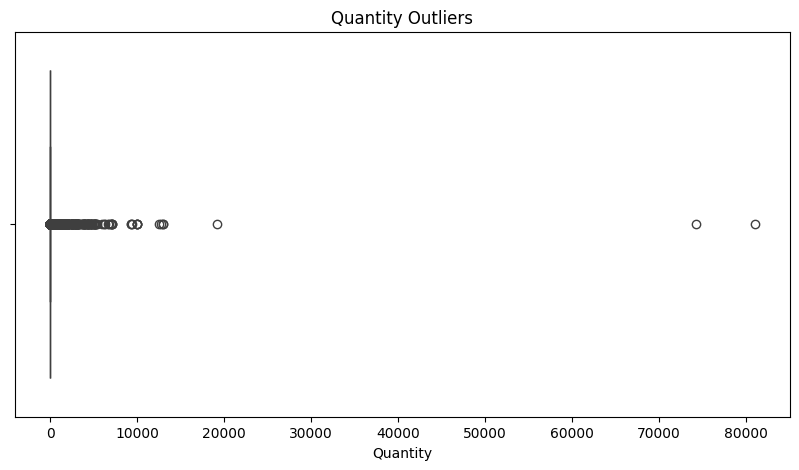

In [33]:
plt.figure(figsize=(10,5))

sns.boxplot(x=df['Quantity'])

plt.title("Quantity Outliers")

plt.show()


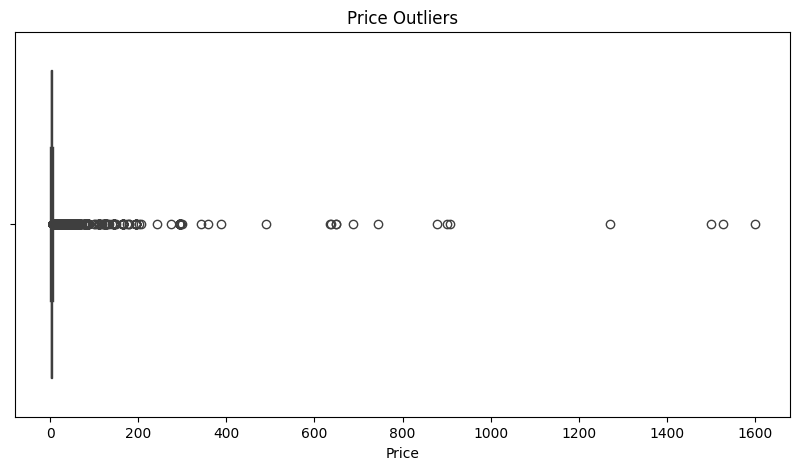

In [34]:
plt.figure(figsize=(10,5))

sns.boxplot(x=df['Price'])

plt.title("Price Outliers")

plt.show()

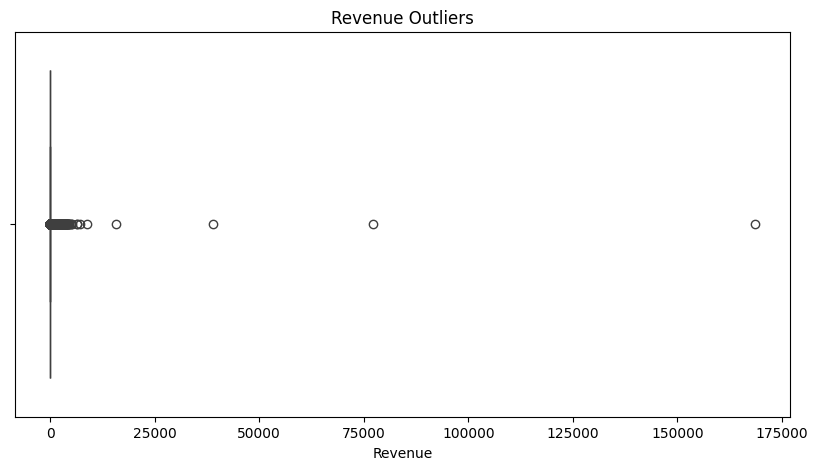

In [35]:
plt.figure(figsize=(10,5))

sns.boxplot(x=df['Revenue'])

plt.title("Revenue Outliers")

plt.show()

In [36]:
df[df['Quantity'] > 20000]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,Year,Month,Day,Hour,Weekday
422013,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,2011-01-18 10:01:00,1.04,12346.0,United Kingdom,77183.6,2011,1,18,10,Tuesday
776480,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2011-12-09 09:15:00,2.08,16446.0,United Kingdom,168469.6,2011,12,9,9,Friday


In [37]:
df[df['Price'] > 5000]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,Year,Month,Day,Hour,Weekday


In [38]:
df[df['Revenue'] > 50000]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,Year,Month,Day,Hour,Weekday
422013,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,2011-01-18 10:01:00,1.04,12346.0,United Kingdom,77183.6,2011,1,18,10,Tuesday
776480,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2011-12-09 09:15:00,2.08,16446.0,United Kingdom,168469.6,2011,12,9,9,Friday


In [39]:
df['Quantity'].quantile([0.90, 0.95, 0.99, 0.999])

0.900     24.0
0.950     36.0
0.990    144.0
0.999    576.0
Name: Quantity, dtype: float64

In [40]:
df['Price'].quantile([0.90, 0.95, 0.99, 0.999])

0.900     6.75
0.950     8.50
0.990    12.75
0.999    39.95
Name: Price, dtype: float64

In [41]:
df['Revenue'].quantile([0.90, 0.95, 0.99, 0.999])

0.900     35.4
0.950     67.5
0.990    201.6
0.999    835.2
Name: Revenue, dtype: float64

In [42]:
#Monthly Revenue Trend
monthly_sales = (
    df.groupby(['Year', 'Month'])['Revenue']
    .sum()
    .reset_index()
)

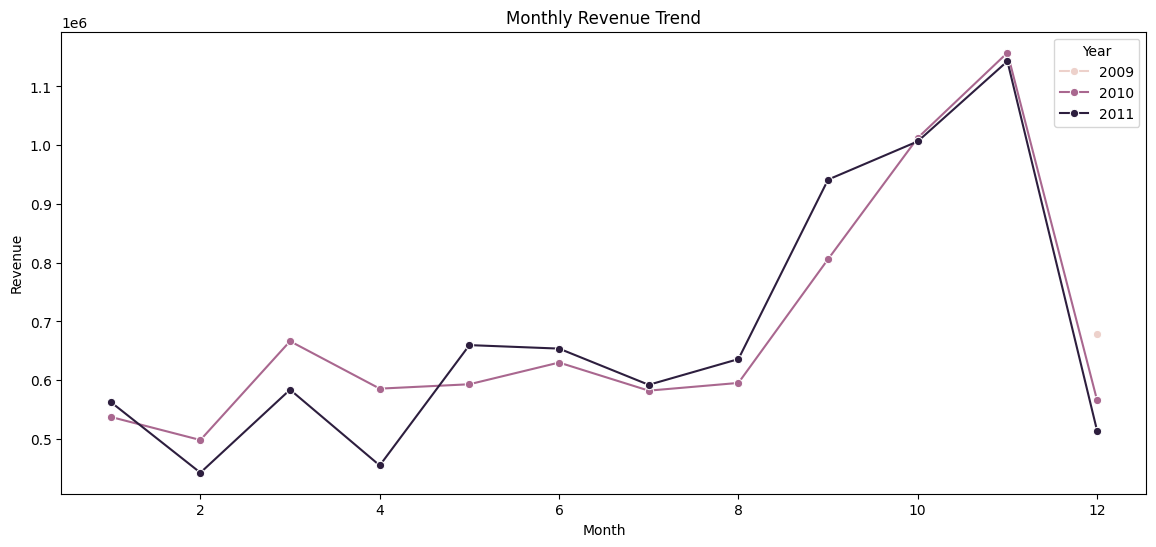

In [58]:
plt.figure(figsize=(14,6))

sns.lineplot(
    data=monthly_sales,
    x='Month',
    y='Revenue',
    hue='Year',
    marker='o'
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

# Save chart
plt.savefig("../outputs/charts/eda/monthly_revenue_trend.png")


plt.show()

Insight
- Revenue peaks significantly during November and December.
- Strong seasonal shopping behavior is visible during the holiday period.
- Sales remain relatively stable during mid-year months.

In [44]:
#Top 10 Countries by Revenue 

#Which countries generate the highest business revenue?

#Aggregate Revenue by Country
top_countries = (
    df.groupby('Country')['Revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

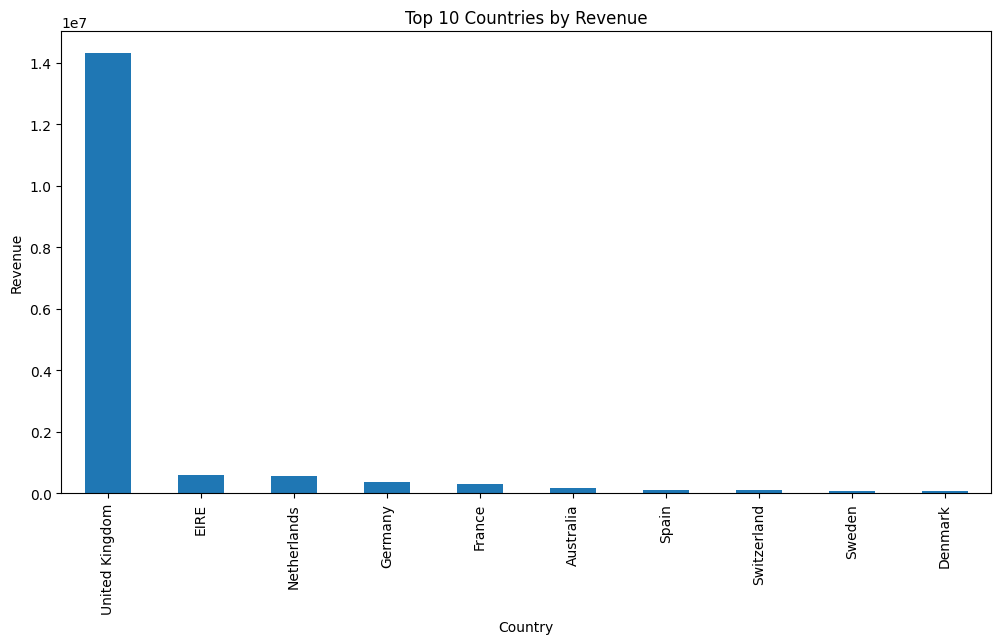

In [45]:
plt.figure(figsize=(12,6))

top_countries.plot(kind='bar')

plt.title("Top 10 Countries by Revenue")
plt.xlabel("Country")
plt.ylabel("Revenue")

plt.show()

Insight
- United Kingdom dominates total revenue generation.
- European countries contribute significantly to international sales.
- The business is heavily concentrated in the UK market.

In [46]:
#Top Non-UK Countries by Revenue
non_uk = (
    df[df['Country'] != 'United Kingdom']
    .groupby('Country')['Revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

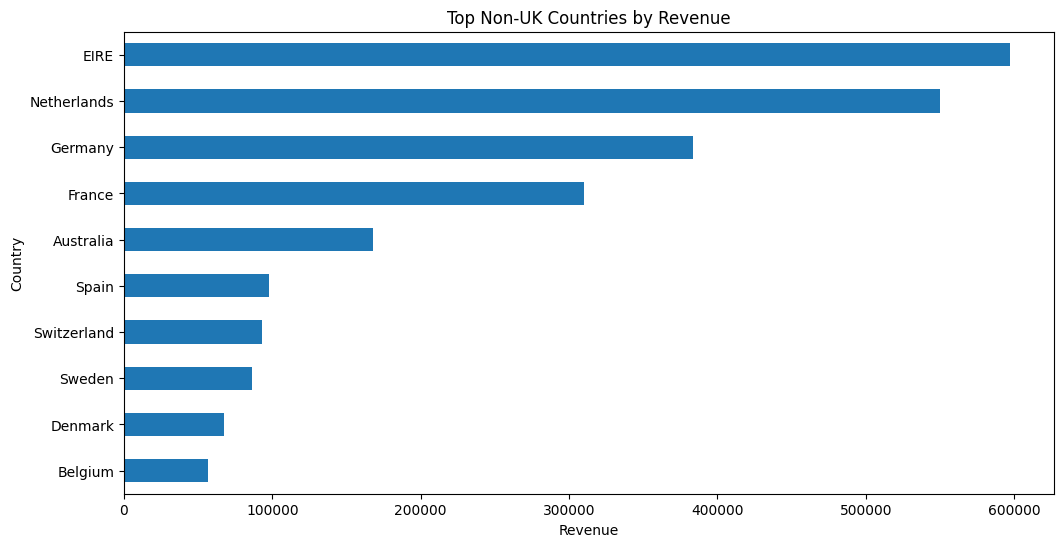

In [47]:
plt.figure(figsize=(12,6))

non_uk.sort_values().plot(kind='barh')

plt.title("Top Non-UK Countries by Revenue")
plt.xlabel("Revenue")

plt.show()

Insight
- EIRE and the Netherlands are the strongest non-UK markets.
- European countries represent the majority of international revenue.
- There is potential for further expansion in European regions.

#Top Selling Products

In [48]:
top_products = (
    df.groupby('Description')['Quantity']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

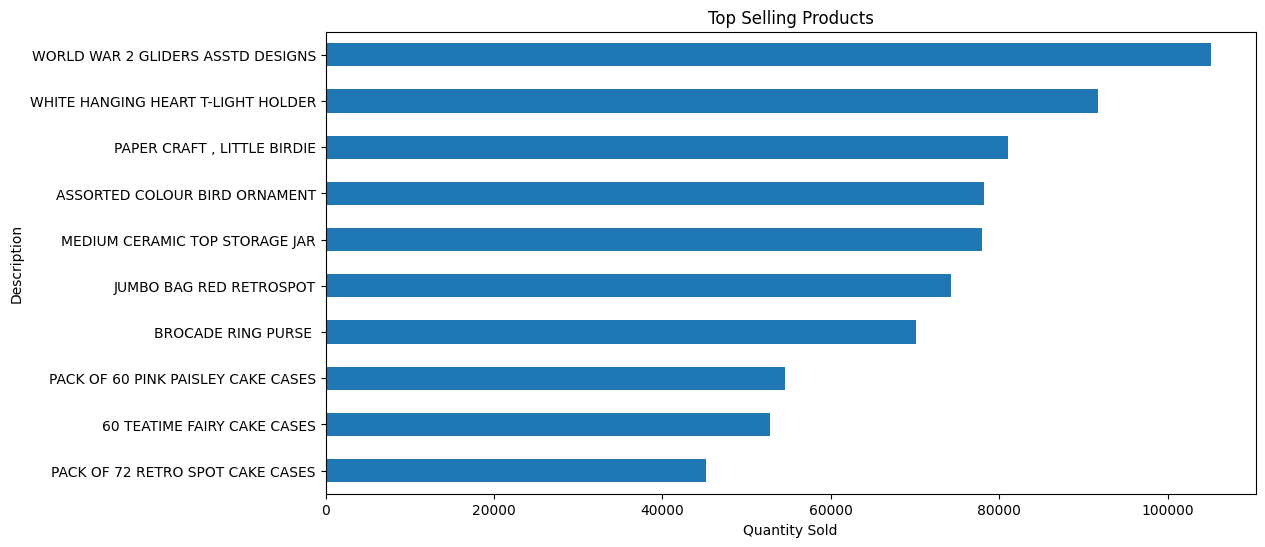

In [49]:
plt.figure(figsize=(12,6))

top_products.sort_values().plot(kind='barh')

plt.title("Top Selling Products")
plt.xlabel("Quantity Sold")

plt.savefig("../outputs/charts/eda/top_selling_products.png")

plt.show()

Insight
- Decorative and giftware products dominate sales quantity.
- Certain products experience extremely high customer demand.
- High-volume products are important for inventory management.

In [50]:
# Top Revenue-Generating Products: Which products generate the most business revenue?


#Aggregate Revenue by Product
top_revenue_products = (
    df.groupby('Description')['Revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

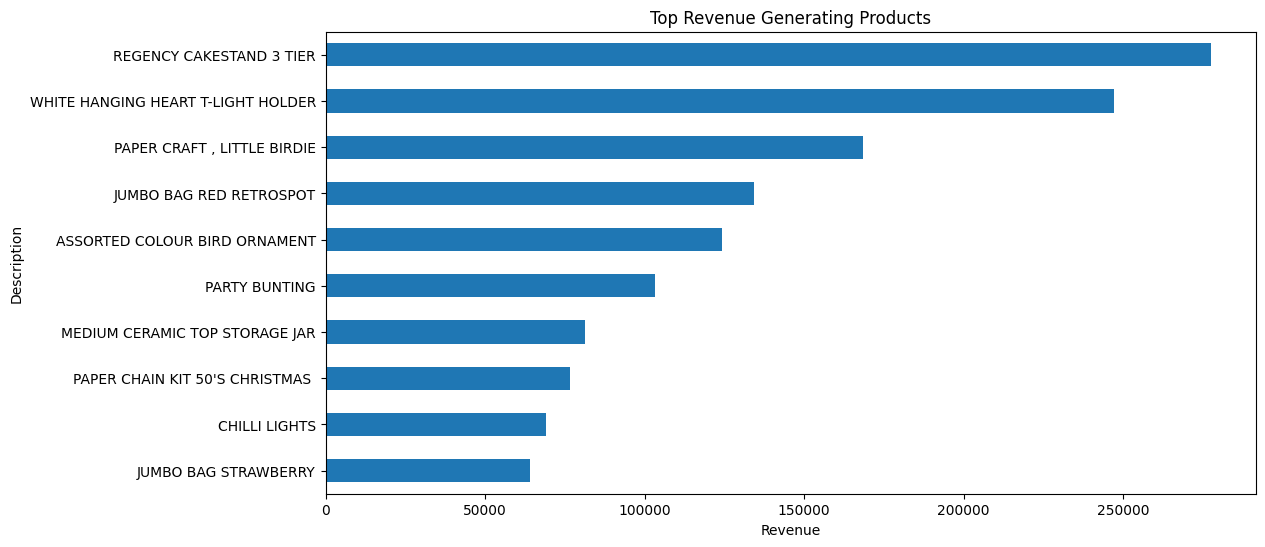

In [51]:
plt.figure(figsize=(12,6))

top_revenue_products.sort_values().plot(kind='barh')

plt.title("Top Revenue Generating Products")
plt.xlabel("Revenue")

plt.savefig("../outputs/charts/eda/top_revenue_products.png")

plt.show()

Insight
- Decorative and giftware products dominate sales quantity.
- Certain products experience extremely high customer demand.
- High-volume products are important for inventory management.

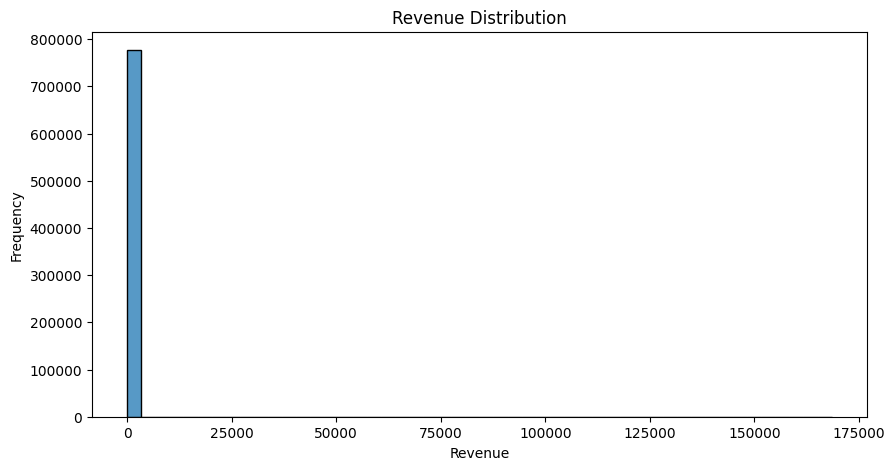

In [52]:
#Revenue Distribution Analysis: How transaction revenue is distributed.  
#Histogram

plt.figure(figsize=(10,5))

sns.histplot(df['Revenue'], bins=50)

plt.title("Revenue Distribution")
plt.xlabel("Revenue")
plt.ylabel("Frequency")

plt.show()

Insight
- Some products generate high revenue despite lower sales volume.
- Premium and high-value products contribute strongly to profitability.
- Revenue contribution varies considerably across products.

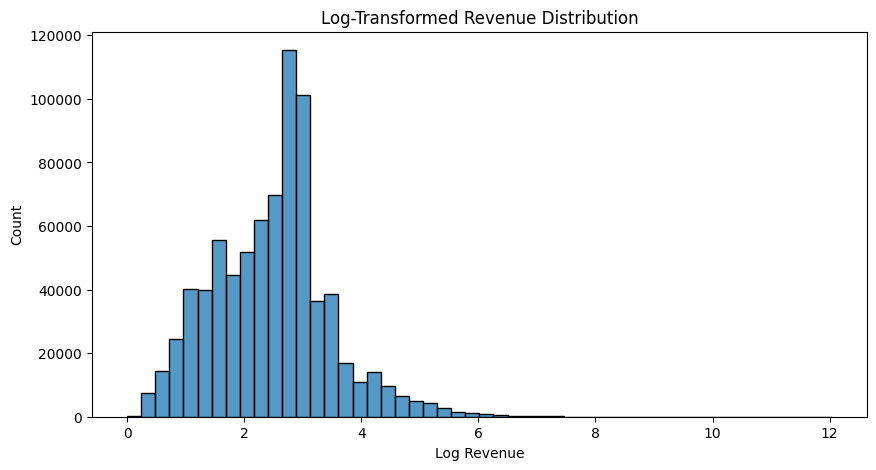

In [53]:
#Log Transformation Visualization
import numpy as np

plt.figure(figsize=(10,5))

sns.histplot(np.log1p(df['Revenue']), bins=50)

plt.title("Log-Transformed Revenue Distribution")
plt.xlabel("Log Revenue")

plt.show()

Insight
- Some products generate high revenue despite lower sales volume.
- Premium and high-value products contribute strongly to profitability.
- Revenue contribution varies considerably across products.

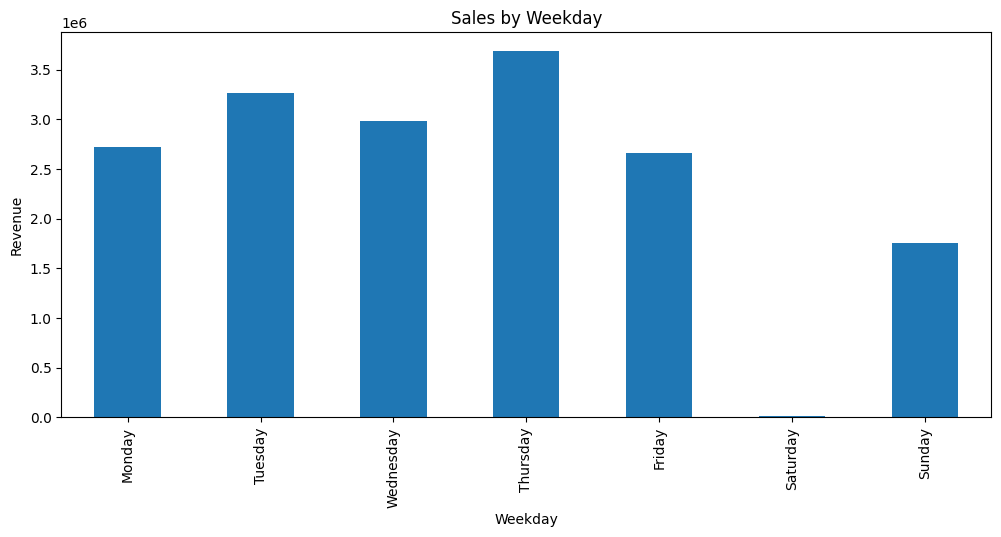

In [54]:
# Sales by Weekday:  Which days generate the highest revenue?

weekday_order = [
    'Monday', 'Tuesday', 'Wednesday',
    'Thursday', 'Friday', 'Saturday', 'Sunday'
]
weekday_sales = (
    df.groupby('Weekday')['Revenue']
    .sum()
    .reindex(weekday_order)

)

plt.figure(figsize=(12,5))

weekday_sales.plot(kind='bar')

plt.title("Sales by Weekday")
plt.xlabel("Weekday")
plt.ylabel("Revenue")

# Save chart
plt.savefig("../outputs/charts/eda/sales_by_weekday.png")

plt.show()

Insight
- Thursday generates the highest revenue among weekdays.
- Weekend sales activity is relatively low.
- Customer purchasing behavior is strongest during weekdays.

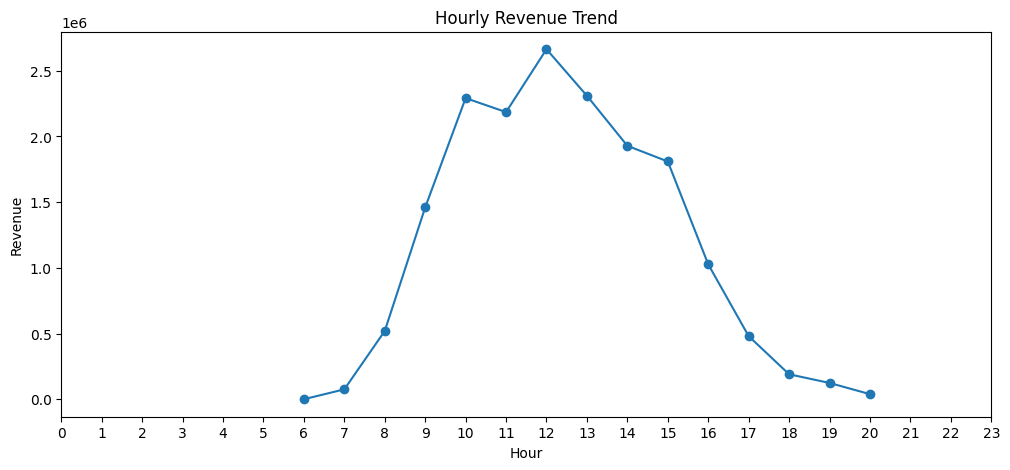

In [55]:
#Hourly Revenue Trend: At what time of day do customers purchase the most?

hourly_sales = df.groupby('Hour')['Revenue'].sum()

plt.figure(figsize=(12,5))

hourly_sales.plot(marker='o')

plt.title("Hourly Revenue Trend")
plt.xlabel("Hour")
plt.ylabel("Revenue")

plt.xticks(range(0,24))

plt.savefig("../outputs/charts/eda/hourly_revenue_trend.png")

plt.show()

Insight
- Revenue peaks between late morning and afternoon hours.
- Sales activity drops significantly during evening hours.
- Customer purchasing behavior aligns with business working hours.

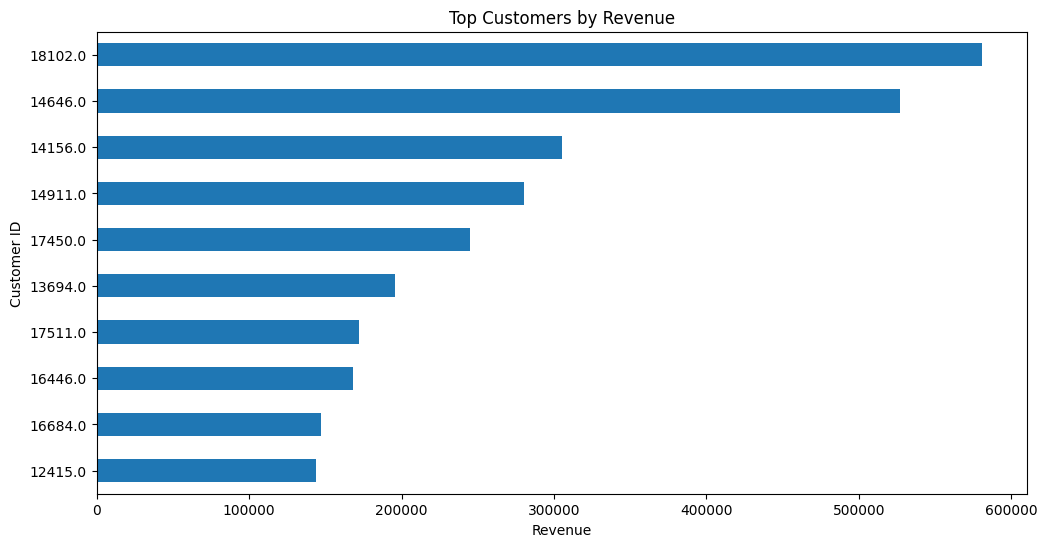

In [56]:
#Top Customers by Revenue: VIP / high-value customers

top_customers = (
    df.groupby('Customer ID')['Revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

top_customers.sort_values().plot(kind='barh')

plt.title("Top Customers by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Customer ID")

plt.savefig("../outputs/charts/eda/top_customers_by_revenue.png")

plt.show()

Insight
- A small group of customers contributes disproportionately high revenue.
- VIP customers are highly important for business profitability.
- Customer revenue distribution follows the Pareto principle.

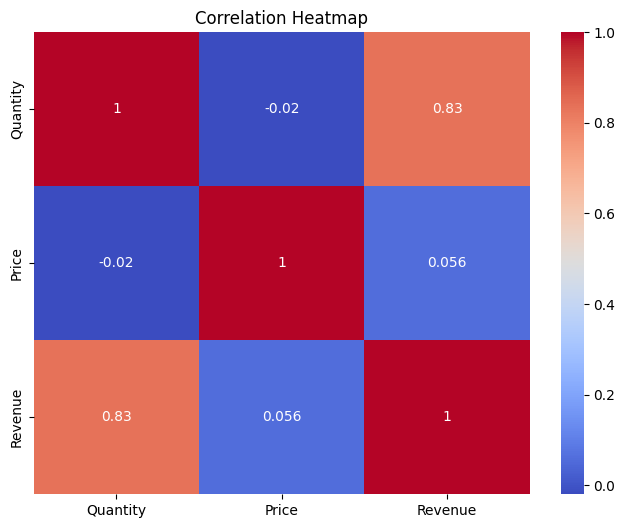

In [57]:
#Correlation Heatmap: How numerical features relate to each other.

correlation_matrix = df[['Quantity', 'Price', 'Revenue']].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

Insight
- Revenue is strongly influenced by product quantity sold.
- Product price has relatively weak correlation with revenue.
- Sales volume contributes more to revenue growth than pricing alone.